In [21]:
## IMPORTS
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline


# CARGA DATOS SIMAR

In [2]:
simar_df = pd.read_excel(os.path.join(BASE_PATH, "DATA", "MASTER", "wave_SIMAR.xlsx"), header=1)

In [3]:
# Convertir 'Fecha (GMT)' a datetime
simar_df['Fecha (GMT)'] = pd.to_datetime(simar_df['Fecha (GMT)'], errors='coerce')

# Convertir 'Altura Signif. del Oleaje(m)' a numérico, manejando errores
simar_df['Altura Signif. del Oleaje(m)'] = pd.to_numeric(simar_df['Altura Signif. del Oleaje(m)'], errors='coerce')

# Eliminar filas donde la fecha o la altura del oleaje sean NaN después de la conversión
simar_df.dropna(subset=['Fecha (GMT)', 'Altura Signif. del Oleaje(m)'], inplace=True)

# Ordenar por fecha para asegurar una correcta visualización de la serie temporal
simar_df.sort_values(by='Fecha (GMT)', inplace=True)

In [14]:
# Filtrar datos por rango de fechas (27 de Febrero al 5 de Marzo)
# Definir el rango de fechas
start_date = '2024-02-27 00:00:00'
end_date = '2024-03-05 23:59:59'

# Filtrar el DataFrame
simar_df_filtered = simar_df[(simar_df['Fecha (GMT)'] >= start_date) & (simar_df['Fecha (GMT)'] <= end_date)]

simar_df_filtered.head()

,Fecha (GMT),Altura Signif. del Oleaje(m),Periodo Medio(s),Periodo de Pico(s),"Direcc. Media de Proced.(0=N,90=E)",Mar de viento: Altura signif. Espectral(m),"Mar de viento: Direcc. Media de Proced.(0=N,90=E)",Mar de fondo 1: Altura signif. Es
1368,2024-02-27 00:00:00,3.05,7.1,12.1,315,-9999.9,-9999.9,2.18
1369,2024-02-27 01:00:00,2.87,7.2,12.1,315,-9999.9,-9999.9,2.06
1370,2024-02-27 02:00:00,2.74,6.9,12.1,315,-9999.9,-9999.9,1.94
1371,2024-02-27 03:00:00,2.65,6.7,12.1,315,-9999.9,-9999.9,1.83
1372,2024-02-27 04:00:00,2.60,6.5,12.1,316,-9999.9,-9999.9,1.72


In [15]:
# Preparar SIMAR para merge por hora relativa ENTERA (SIMAR viene sin decimales)
start_date_dt = pd.to_datetime(start_date)

simar_merge = simar_df_filtered[["Fecha (GMT)", "Altura Signif. del Oleaje(m)"]].copy()
simar_merge["hour"] = (simar_merge["Fecha (GMT)"] - start_date_dt).dt.total_seconds() / 3600

# Clave entera para merge con df_flux
simar_merge["hour_int"] = np.trunc(simar_merge["hour"]).astype(int)

# Si hay filas repetidas dentro de la misma hora, se promedian
simar_merge = (
    simar_merge
    .groupby("hour_int", as_index=False)["Altura Signif. del Oleaje(m)"]
    .mean()
    .rename(columns={"Altura Signif. del Oleaje(m)": "Oleaje_SIMAR"})
)

simar_merge.head()

,hour_int,Oleaje_SIMAR
0,0,3.05
1,1,2.87
2,2,2.74
3,3,2.65
4,4,2.60


# CARGA DATOS VELOCIDAD ORBITAL

In [8]:
v_orb_df = pd.read_excel(os.path.join(BASE_PATH, "DATA", "MASTER", "orbital_velocity.xlsx"), header=1)
df_flux= pd.read_csv(os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_flux.csv"), sep=r",")

In [9]:
df_flux['hour'] = np.trunc(df_flux['hour'] * 100) / 100

In [16]:
v_orb_df.rename(columns={'Time Mean': 'hour'}, inplace=True)

# Merge 1: df_flux + variables de velocidad orbital (con hora decimal)
df_merged = pd.merge(
    df_flux,
    v_orb_df[['hour', 'Oleaje', 'Mod_orbital', 'STD_orbital']],
    on='hour',
    how='left'
)

# Merge 2: añadir ola de SIMAR con clave de hora entera
# (SIMAR no trae decimales en la hora)
df_merged["hour_int"] = np.trunc(df_merged["hour"]).astype(int)
df_merged = pd.merge(
    df_merged,
    simar_merge[['hour_int', 'Oleaje_SIMAR']],
    on='hour_int',
    how='left'
)

df_merged.head()

,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vz,mean_O2,...,flux_smooth,flag_outlier_global,flag_outlier_window,flag_flux_positivo,flag_vz_baja,Oleaje,Mod_orbital,STD_orbital,hour_int,Oleaje_SIMAR
0,0,13.12,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-0.000940,219.341074,...,-6.351335,False,False,False,False,9.664,0.015203,0.009969,13,1.87
1,1,13.37,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-0.001864,220.214211,...,-6.745481,False,False,False,False,9.876,0.015946,0.010475,13,1.87
2,2,13.62,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-0.001838,220.537457,...,-6.619435,False,False,False,False,9.004,0.013689,0.008438,13,1.87
3,3,13.87,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.001537,220.398051,...,-6.799723,False,False,False,False,8.556,0.012808,0.008059,13,1.87
4,4,14.12,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.001444,220.429227,...,-6.911006,False,False,False,False,9.500,0.013456,0.007926,14,1.86


# COMPARACIÓN OLAS

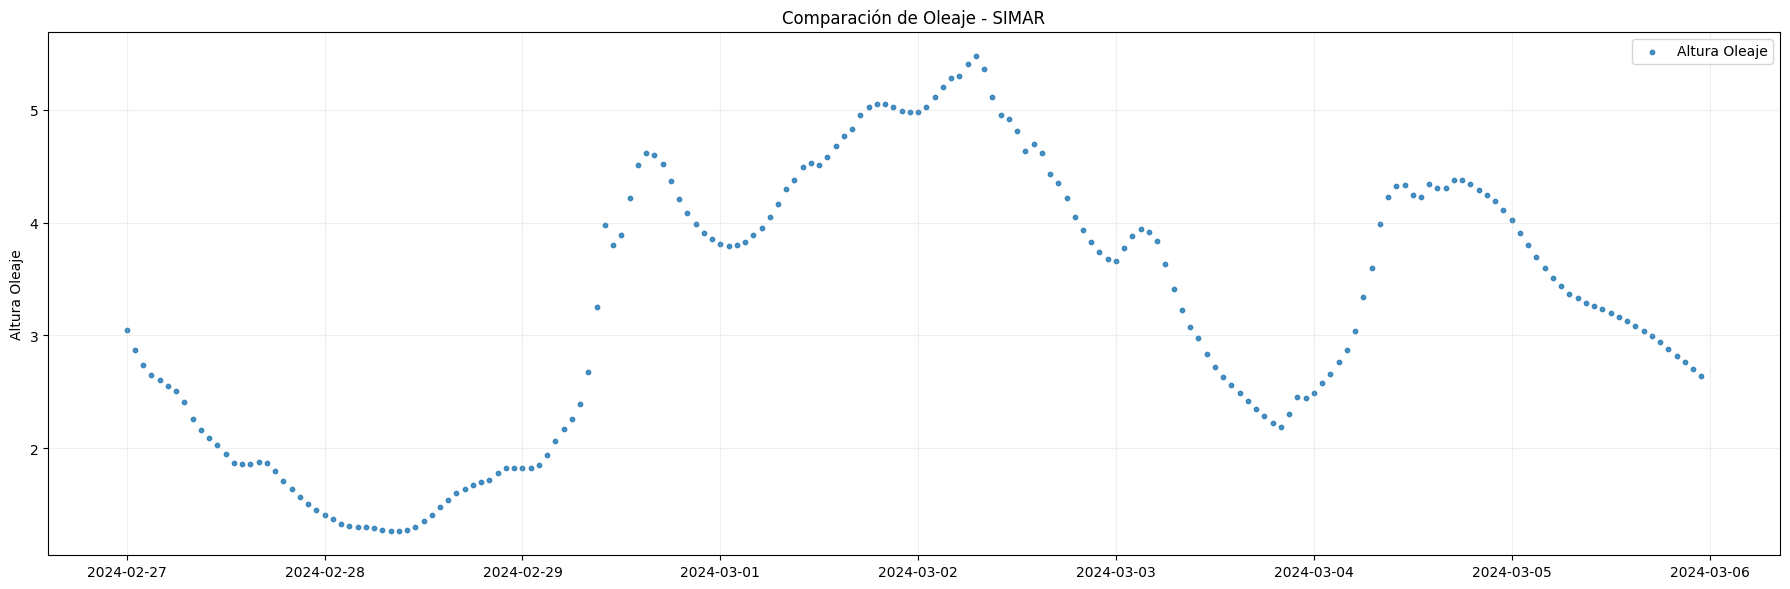

In [17]:
plt.figure(figsize=(18, 6))

# SIMAR
plt.scatter(
    simar_df_filtered["Fecha (GMT)"],
    simar_df_filtered["Altura Signif. del Oleaje(m)"],
    alpha=0.8,
    s=10, # Marker size
    label="Altura Oleaje"
)
plt.ylabel("Altura Oleaje")
plt.title("Comparación de Oleaje - SIMAR")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

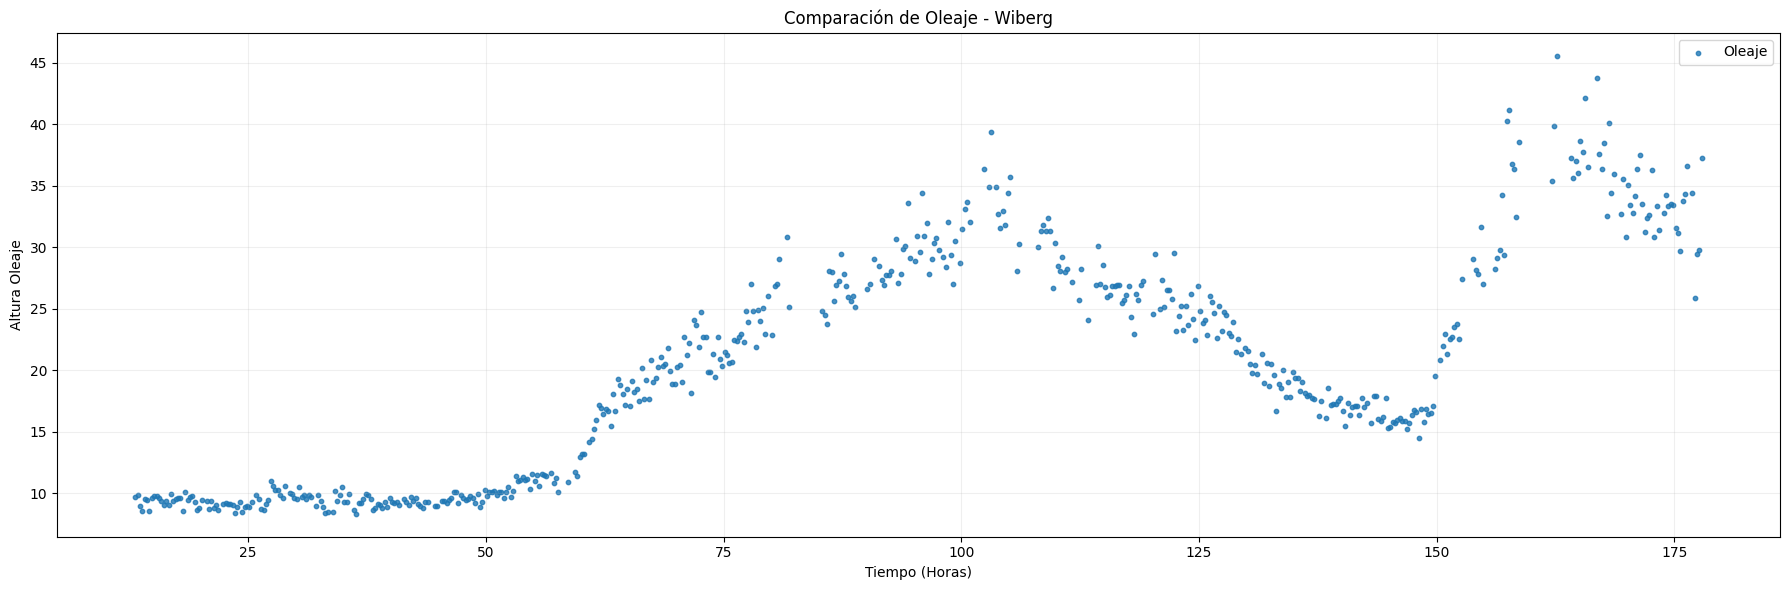

In [ ]:
plt.figure(figsize=(18, 6))

# WIBERG
plt.scatter(
    df_merged["hour"],
    df_merged["Oleaje"],
    alpha=0.8,
    s=10, # Marker size
    label="Oleaje"
)
plt.xlabel("Tiempo (Horas)")
plt.ylabel("Altura Oleaje")
plt.title("Comparación de Oleaje - Wiberg")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# MERGEO DE DATOS DE OLEAJE Y RENOMBRADO DE COLUMNAS

In [19]:
df_oleaje = df_merged
df_oleaje.head()

,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vz,mean_O2,...,flux_smooth,flag_outlier_global,flag_outlier_window,flag_flux_positivo,flag_vz_baja,Oleaje,Mod_orbital,STD_orbital,hour_int,Oleaje_SIMAR
0,0,13.12,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-0.000940,219.341074,...,-6.351335,False,False,False,False,9.664,0.015203,0.009969,13,1.87
1,1,13.37,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-0.001864,220.214211,...,-6.745481,False,False,False,False,9.876,0.015946,0.010475,13,1.87
2,2,13.62,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-0.001838,220.537457,...,-6.619435,False,False,False,False,9.004,0.013689,0.008438,13,1.87
3,3,13.87,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.001537,220.398051,...,-6.799723,False,False,False,False,8.556,0.012808,0.008059,13,1.87
4,4,14.12,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.001444,220.429227,...,-6.911006,False,False,False,False,9.500,0.013456,0.007926,14,1.86


In [20]:
output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_wave.csv")
df_oleaje.to_csv(output_path, index=False)
print(f"Datos guardados exitosamente en: {output_path}")

Datos guardados exitosamente en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline\DATA\PROCESSED\df_wave.csv
